In [5]:
import pandas as pd
import os
import numpy as np
from datetime import datetime

In [6]:
nivel3_2018 = pd.read_csv('secoes_criticas_2018.csv', sep=';', encoding='utf-8-sig')
nivel3_2022 = pd.read_csv('secoes_criticas_2022.csv', sep=';', encoding='utf-8-sig')

recorrentes = nivel3_2018.merge(
    nivel3_2022,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

print(f"Seções recorrentes: {len(recorrentes)}")
display(recorrentes)

Seções recorrentes: 1


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO_x,CONTINGENCIA_x,QT_ELEITORES_ANTES_17_x,DELTA_T_ANTES_17_x,DESVIO_ANTES_17_x,QT_ELEITORES_DEPOIS_17_x,DELTA_T_DEPOIS_17_x,...,QT_ELEITORES_DEPOIS_17_y,DELTA_T_DEPOIS_17_y,DESVIO_DEPOIS_17_y,ULTIMO_VOTO_y,TIMEOUT_BIOMETRIA_y,TECLA_INDEVIDA_y,INATIVIDADE_y,SEM_BIOMETRIA_y,ATRASO_FILA_MINUTOS_y,STATUS_y
0,Riachão Do Dantas,4,151,1º Turno,Não,229,82.4,62.72,83,81.71,...,106,79.92,50.52,20:42:28,16,1096,21,21,222,3


In [7]:
atraso_2018 = pd.read_csv('df_atraso_2018.csv', sep=';', encoding='utf-8-sig')
atraso_2022 = pd.read_csv('df_atraso_2022.csv', sep=';', encoding='utf-8-sig')

recorrentes1 = atraso_2018.merge(
    atraso_2022,
    on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

print(f"Seções recorrentes: {len(recorrentes1)}")
display(recorrentes1)

Seções recorrentes: 1068


,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO_x,CONTINGENCIA_x,QT_ELEITORES_ANTES_17_x,DELTA_T_ANTES_17_x,DESVIO_ANTES_17_x,QT_ELEITORES_DEPOIS_17_x,DELTA_T_DEPOIS_17_x,...,QT_ELEITORES_DEPOIS_17_y,DELTA_T_DEPOIS_17_y,DESVIO_DEPOIS_17_y,ULTIMO_VOTO_y,TIMEOUT_BIOMETRIA_y,TECLA_INDEVIDA_y,INATIVIDADE_y,SEM_BIOMETRIA_y,ATRASO_FILA_MINUTOS_y,STATUS_y
0,Tomar Do Geru,30,36,1º Turno,Não,243,77.65,47.63,3,99.00,...,9,51.78,12.55,17:14:51,8,414,7,1,14,1
1,Tomar Do Geru,30,24,1º Turno,Não,252,72.73,50.82,4,54.00,...,31,66.68,27.15,18:00:41,11,433,23,0,60,2
2,Tomar Do Geru,30,49,1º Turno,Não,177,89.76,59.97,21,86.86,...,39,92.85,73.10,18:21:18,11,569,16,11,81,2
3,Tomar Do Geru,30,26,1º Turno,Não,243,72.92,70.77,3,122.33,...,23,81.13,116.88,17:55:01,7,373,7,0,55,2
4,Macambira,24,21,1º Turno,Não,301,71.88,56.30,11,47.09,...,40,59.68,33.05,18:17:14,37,669,4,1,77,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,Boquim,4,188,1º Turno,Não,275,72.55,52.47,28,66.18,...,54,61.57,32.69,18:36:55,6,717,12,0,96,2
1064,Boquim,4,172,1º Turno,Não,253,63.76,51.84,32,59.06,...,43,60.49,42.49,18:25:26,10,606,9,16,85,2
1065,Boquim,4,150,1º Turno,Não,229,75.72,69.04,14,76.86,...,41,63.05,26.72,18:13:45,16,761,15,17,73,2
1066,Boquim,4,179,1º Turno,Não,228,83.76,70.30,53,59.02,...,33,69.97,39.66,17:59:43,1,775,16,1,59,2


C:\Users\joaop\AppData\Local\Temp\ipykernel_14860\2075912903.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


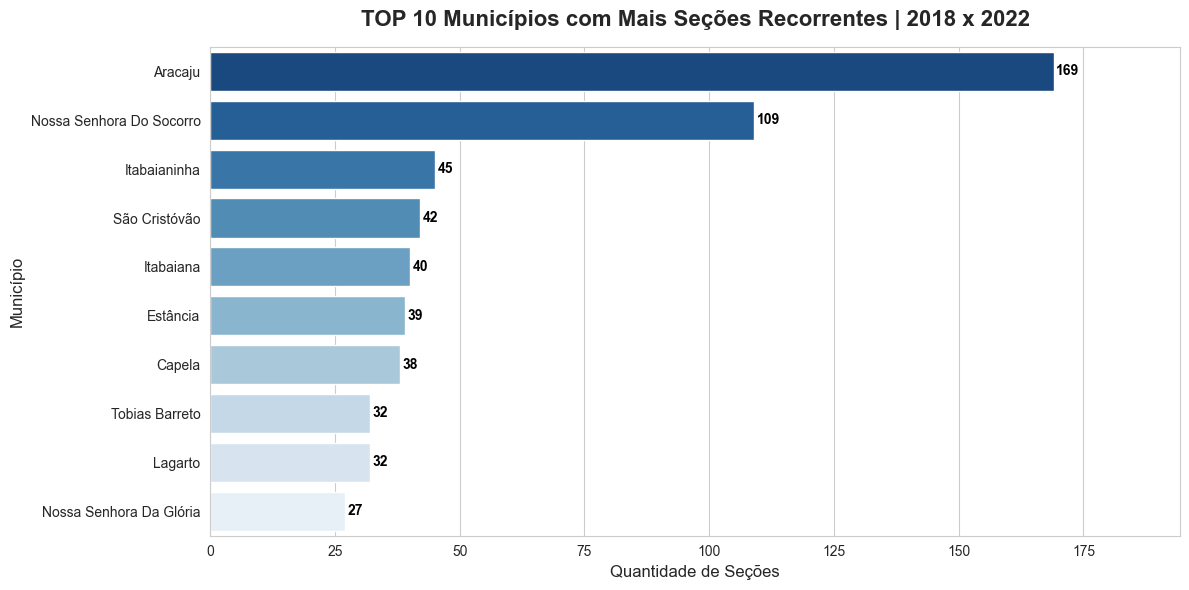

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Prepara os dados
top10 = recorrentes1['NM_MUNICIPIO'].value_counts().head(10).reset_index()
top10.columns = ['Município', 'Qtd_Urnas_Recorrentes']

# 2. Configura o tamanho
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Desenha o gráfico
grafico = sns.barplot(
    x='Qtd_Urnas_Recorrentes', 
    y='Município', 
    data=top10, 
    palette='Blues_r'
)

# 4. Adiciona os números nas barras
for index, value in enumerate(top10['Qtd_Urnas_Recorrentes']):
    grafico.text(value + 0.5, index, str(value), color='black', va='center', fontweight='bold')

# 5. Títulos e eixos
plt.title('TOP 10 Municípios com Mais Seções Recorrentes | 2018 x 2022', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Seções', fontsize=12)
plt.ylabel('Município', fontsize=12)
plt.xlim(0, top10['Qtd_Urnas_Recorrentes'].max() * 1.15)

plt.tight_layout()
plt.show()